# 1. Carga y exploración de datos

## 1.1 Diccionario de datos

| Campo             | Descripción                                     |
|------------------|--------------------------------------------------------------|
| transaction_id   | ID único secuencial que representa una transacción individual |
| transaction_date | Fecha de la transacción (MM/DD/AA)                           |
| transaction_time | Hora exacta de la transacción (HH:MM:SS)                     |
| transaction_qty  | Cantidad de productos vendidos                               |
| store_id         | ID único de la cafetería donde ocurrió la transacción        |
| store_location   | Ubicación de la cafetería donde ocurrió la transacción       |
| product_id       | ID único del producto vendido                                |
| unit_price       | Precio de venta del producto                                 |
| product_category | Descripción de la categoría del producto                     |
| product_type     | Descripción del tipo de producto                             |
| product_detail   | Descripción detallada del producto                           |

## 1.2 Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
df = pd.read_excel('Coffee Shop Sales.xlsx')
# Display the first few rows of the dataset
print(df.head())

   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2   
2               3       2023-01-01         07:14:04                2   
3               4       2023-01-01         07:20:24                1   
4               5       2023-01-01         07:22:41                2   

   store_id   store_location  product_id  unit_price    product_category  \
0         5  Lower Manhattan          32         3.0              Coffee   
1         5  Lower Manhattan          57         3.1                 Tea   
2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
3         5  Lower Manhattan          22         2.0              Coffee   
4         5  Lower Manhattan          57         3.1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee                  Ethiopia Rg 

## 1.3 Exploración básica de datos

In [2]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [3]:
df.describe(include='object')

,transaction_time,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,25762,3,9,29,80
top,09:31:15,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,41,50735,58416,17183,3076


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


## 1.4 Outliers

### 1.4.1 Valores vacíos

In [5]:
df.isna().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

### 1.4.2 Valores duplicados

In [6]:
df.duplicated().sum()

np.int64(0)

### 1.4.3 Valores fuera de rango

Se dará por hecho que los datos númericos no tienen valores atípicos dentro de sus rangos.

## 1.5 Información acerca de los productos y sucursales

In [7]:
# Mostrar el numero de tiendas y localidades distintas
print("Número de tiendas distintas:", df["store_location"].nunique())
print("Número de localidades distintas:", df["store_location"].nunique())
print("------------------------------------------")
print("Tiendas distintas:", df["store_location"].unique())

Número de tiendas distintas: 3
Número de localidades distintas: 3
------------------------------------------
Tiendas distintas: ['Lower Manhattan' "Hell's Kitchen" 'Astoria']


In [8]:
# Mostrar los diferentes productos y tipos de productos
print("Número de productos distintos:", df["product_id"].nunique())
print("Número de tipos de productos distintos:", df["product_type"].nunique())
print("------------------------------------------")
print("Productos distintos:", df["product_type"].unique())

Número de productos distintos: 80
Número de tipos de productos distintos: 29
------------------------------------------
Productos distintos: ['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone' 'Barista Espresso' 'Brewed Black tea' 'Brewed Green tea'
 'Brewed herbal tea' 'Biscotti' 'Pastry' 'Organic brewed coffee'
 'Premium brewed coffee' 'Regular syrup' 'Herbal tea' 'Gourmet Beans'
 'Organic Beans' 'Sugar free syrup' 'Drinking Chocolate' 'Premium Beans'
 'Chai tea' 'Green beans' 'Espresso Beans' 'Green tea' 'Organic Chocolate'
 'Housewares' 'Black tea' 'House blend Beans' 'Clothing']


In [9]:
# Mostrar las diferentes categorías de productos
print("Número de categorías de productos distintas:", df["product_category"].nunique())
print("------------------------------------------")
print("Categorías de productos distintas:", df["product_category"].unique())

Número de categorías de productos distintas: 9
------------------------------------------
Categorías de productos distintas: ['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']


## 1.6 Preparación del conjunto de datos

In [10]:
# Eliminar columnas innecesarias y crear una nueva columna de ventas totales
df.drop(columns=["product_detail", "store_id", "product_id"], inplace=True)
df["total_sale"] = df["transaction_qty"] * df["unit_price"]
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_location', 'unit_price', 'product_category',
       'product_type', 'total_sale'],
      dtype='object')

In [11]:
# Convertir la columna de fecha a formato datetime y extraer características temporales
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["month"] = df["transaction_date"].dt.month
df["weekday"] = df["transaction_date"].dt.weekday
df["number_day"] = df["transaction_date"].dt.day
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
df['week'] = df['transaction_date'].dt.to_period('W')
df['week'] = df['week'].dt.start_time
df['number_week'] = df['transaction_date'].dt.isocalendar().week

In [12]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,total_sale,month,weekday,number_day,hour,week,number_week
0,1,2023-01-01,07:06:11,2,Lower Manhattan,3.0,Coffee,Gourmet brewed coffee,6.0,1,6,1,7,2022-12-26,52
1,2,2023-01-01,07:08:56,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,6.2,1,6,1,7,2022-12-26,52
2,3,2023-01-01,07:14:04,2,Lower Manhattan,4.5,Drinking Chocolate,Hot chocolate,9.0,1,6,1,7,2022-12-26,52
3,4,2023-01-01,07:20:24,1,Lower Manhattan,2.0,Coffee,Drip coffee,2.0,1,6,1,7,2022-12-26,52
4,5,2023-01-01,07:22:41,2,Lower Manhattan,3.1,Tea,Brewed Chai tea,6.2,1,6,1,7,2022-12-26,52


## 1.7 Conjunto de datos final

# 2. Análisis de ventas en el tiempo

**Objetivo:**  
Evaluar la evolución de las ventas para identificar tendencias, patrones de crecimiento y anomalías en el tiempo.

**Tipo de análisis:**  
Descriptivo

**Modelo de análisis:**  
Se analizarán las ventas a nivel diario, semanal y mensual utilizando técnicas de agregación temporal (time series aggregation).  
Se aplicarán métricas como ingresos totales, número de transacciones y ticket promedio, crecimiento de ventas porcentual.

## 2.1 Agregación de datos temporales

### 2.1.1 Diario

In [13]:
# Agrupar venta total y número de transacciones por día
ventas_global_diarias = df.groupby("transaction_date", as_index=False).agg(
    total_sale=("total_sale", "sum"),
    transactions=("transaction_id", "count")
)
print(ventas_global_diarias.head())

  transaction_date  total_sale  transactions
0       2023-01-01     2508.20           550
1       2023-01-02     2403.35           566
2       2023-01-03     2565.00           582
3       2023-01-04     2220.10           497
4       2023-01-05     2418.85           547


### 2.1.2 Semanal

In [14]:
# Agrupar venta total y número de transacciones por semana
ventas_global_semanales = df.groupby("week", as_index=False).agg(
    total_sale=("total_sale", "sum"),
    transactions=("transaction_id", "count")
)
print(ventas_global_semanales.head())

        week  total_sale  transactions
0 2022-12-26     2508.20           550
1 2023-01-02    17139.33          3825
2 2023-01-09    19129.53          4113
3 2023-01-16    19818.51          4029
4 2023-01-23    18271.63          3854


### 2.1.3 Mensual

In [15]:
# Agrupar venta total y número de transacciones por mes
ventas_global_mensuales = df.groupby("month", as_index=False).agg(
    total_sale=("total_sale", "sum"),
    transactions=("transaction_id", "count")
)
print(ventas_global_mensuales)

   month  total_sale  transactions
0      1    81677.74         17314
1      2    76145.19         16359
2      3    98834.68         21229
3      4   118941.08         25335
4      5   156727.76         33527
5      6   166485.88         35352


## 2.2 Cálculo de métricas

### 2.2.1 Ticket promedio

In [16]:
# Ticket promedio por día
ventas_global_diarias["ticket_promedio"] = ventas_global_diarias["total_sale"] / ventas_global_diarias["transactions"]
print("** TICKET PROMEDIO POR DÍA **")
print(ventas_global_diarias.head())

** TICKET PROMEDIO POR DÍA **
  transaction_date  total_sale  transactions  ticket_promedio
0       2023-01-01     2508.20           550         4.560364
1       2023-01-02     2403.35           566         4.246201
2       2023-01-03     2565.00           582         4.407216
3       2023-01-04     2220.10           497         4.467002
4       2023-01-05     2418.85           547         4.422029


In [17]:
# Ticket promedio por semana
ventas_global_semanales["ticket_promedio"] = ventas_global_semanales["total_sale"] / ventas_global_semanales["transactions"]
print("** TICKET PROMEDIO POR SEMANA **")
print(ventas_global_semanales.head())

** TICKET PROMEDIO POR SEMANA **
        week  total_sale  transactions  ticket_promedio
0 2022-12-26     2508.20           550         4.560364
1 2023-01-02    17139.33          3825         4.480871
2 2023-01-09    19129.53          4113         4.650992
3 2023-01-16    19818.51          4029         4.918965
4 2023-01-23    18271.63          3854         4.740952


In [18]:
# Ticket promedio por mes
ventas_global_mensuales["ticket_promedio"] = ventas_global_mensuales["total_sale"] / ventas_global_mensuales["transactions"]
print("** TICKET PROMEDIO POR MES **")
print(ventas_global_mensuales)

** TICKET PROMEDIO POR MES **
   month  total_sale  transactions  ticket_promedio
0      1    81677.74         17314         4.717439
1      2    76145.19         16359         4.654636
2      3    98834.68         21229         4.655645
3      4   118941.08         25335         4.694734
4      5   156727.76         33527         4.674673
5      6   166485.88         35352         4.709377


### 2.2.2 Crecimiento porcentual

In [19]:
# Crecimiento diario
ventas_global_diarias['crecimiento_%'] = ventas_global_diarias['total_sale'].pct_change() * 100
print("** CRECIMIENTO DIARIO **")
print(ventas_global_diarias.head())

** CRECIMIENTO DIARIO **
  transaction_date  total_sale  transactions  ticket_promedio  crecimiento_%
0       2023-01-01     2508.20           550         4.560364            NaN
1       2023-01-02     2403.35           566         4.246201      -4.180289
2       2023-01-03     2565.00           582         4.407216       6.726028
3       2023-01-04     2220.10           497         4.467002     -13.446394
4       2023-01-05     2418.85           547         4.422029       8.952299


In [20]:
# Crecimiento semanal
ventas_global_semanales['crecimiento_%'] = ventas_global_semanales['total_sale'].pct_change() * 100
print("** CRECIMIENTO SEMANAL **")
print(ventas_global_semanales.head())

** CRECIMIENTO SEMANAL **
        week  total_sale  transactions  ticket_promedio  crecimiento_%
0 2022-12-26     2508.20           550         4.560364            NaN
1 2023-01-02    17139.33          3825         4.480871     583.331871
2 2023-01-09    19129.53          4113         4.650992      11.611889
3 2023-01-16    19818.51          4029         4.918965       3.601657
4 2023-01-23    18271.63          3854         4.740952      -7.805229


In [21]:
# Crecimiento mensual
ventas_global_mensuales['crecimiento_%'] = ventas_global_mensuales['total_sale'].pct_change() * 100
print("** CRECIMIENTO MENSUAL **")
print(ventas_global_mensuales)

** CRECIMIENTO MENSUAL **
   month  total_sale  transactions  ticket_promedio  crecimiento_%
0      1    81677.74         17314         4.717439            NaN
1      2    76145.19         16359         4.654636      -6.773633
2      3    98834.68         21229         4.655645      29.797667
3      4   118941.08         25335         4.694734      20.343466
4      5   156727.76         33527         4.674673      31.769242
5      6   166485.88         35352         4.709377       6.226159


### 2.2.3 Históricos máximos y mínimos de ventas

In [22]:
# Calcular venta máxima y mínima diaria
max_ventas_diarias = ventas_global_diarias["total_sale"].max()
min_ventas_diarias = ventas_global_diarias["total_sale"].min()
print("Venta máxima diaria:", max_ventas_diarias)
print("Venta mínima diaria:", min_ventas_diarias)

Venta máxima diaria: 6403.91
Venta mínima diaria: 2037.1


In [23]:
# Calcular venta máxima y mínima semanal
max_ventas_semanales = ventas_global_semanales["total_sale"].max()
min_ventas_semanales = ventas_global_semanales["total_sale"].min()
print("Venta máxima semanal:", max_ventas_semanales)
print("Venta mínima semanal:", min_ventas_semanales)

Venta máxima semanal: 41315.94
Venta mínima semanal: 2508.2


In [24]:
# Calcular venta máxima y mínima mensual
max_ventas_mensuales = ventas_global_mensuales["total_sale"].max()
min_ventas_mensuales = ventas_global_mensuales["total_sale"].min()
print("Venta máxima mensual:", max_ventas_mensuales)
print("Venta mínima mensual:", min_ventas_mensuales)

Venta máxima mensual: 166485.88
Venta mínima mensual: 76145.19


### 2.2.4 Promedio de ingresos

In [25]:
# Calcular promedio de ventas diarias
promedio_ventas_diarias = ventas_global_diarias["total_sale"].mean()
print("Promedio de ventas diarias:", promedio_ventas_diarias)

Promedio de ventas diarias: 3860.841602209945


In [26]:
# Calcular promedio de ventas semanales
promedio_ventas_semanales = ventas_global_semanales["total_sale"].mean()
print("Promedio de ventas semanales:", promedio_ventas_semanales)

Promedio de ventas semanales: 25881.938148148147


In [27]:
promedio_ventas_mensuales = ventas_global_mensuales["total_sale"].mean()
print("Promedio de ventas mensuales:", promedio_ventas_mensuales)

Promedio de ventas mensuales: 116468.72166666666


### 2.2.5 Promedio móvil

In [28]:
# Calcular media móvil de 7 días para ventas diarias
ventas_global_diarias['media_movil_7'] = ventas_global_diarias['total_sale'].rolling(7).mean()
print("Media móvil de 7 días para ventas diarias:\n", ventas_global_diarias['media_movil_7'].tail())

Media móvil de 7 días para ventas diarias:
 176    5748.121429
177    5816.834286
178    5662.622857
179    5496.287143
180    5453.352857
Name: media_movil_7, dtype: float64


In [29]:
# Calcular media movil de 4 semanas para ventas semanales
ventas_global_semanales['media_movil_4'] = ventas_global_semanales['total_sale'].rolling(4).mean()
print("Media móvil de 4 semanas para ventas semanales:\n", ventas_global_semanales['media_movil_4'].tail())

Media móvil de 4 semanas para ventas semanales:
 22    36263.2400
23    36613.3350
24    37323.1825
25    38363.1175
26    36512.6450
Name: media_movil_4, dtype: float64


In [30]:
# Calcular media móvil de 2 meses para ventas mensuales
ventas_global_mensuales['media_movil_2'] = ventas_global_mensuales['total_sale'].rolling(2).mean()
print("Media móvil de 2 meses para ventas mensuales:\n", ventas_global_mensuales['media_movil_2'].tail())

Media móvil de 2 meses para ventas mensuales:
 1     78911.465
2     87489.935
3    108887.880
4    137834.420
5    161606.820
Name: media_movil_2, dtype: float64


## 2.3 Visualización de datos

### 2.3.1 Gráfico de ventas en el tiempo

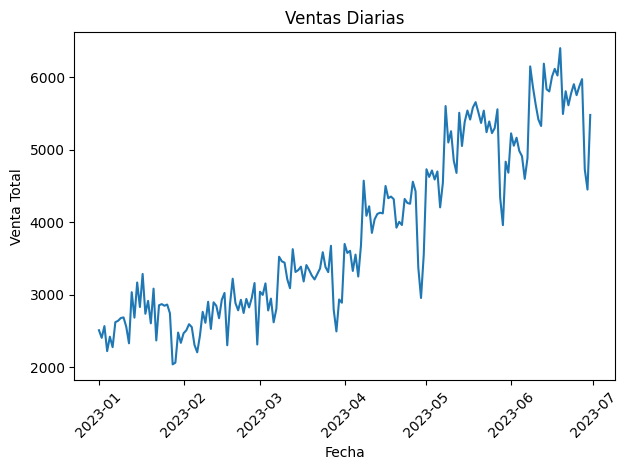

In [31]:
# Visualizar ventas diarias
sns.lineplot(data=ventas_global_diarias, x="transaction_date", y="total_sale")
plt.title("Ventas Diarias")
plt.xlabel("Fecha")
plt.ylabel("Venta Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

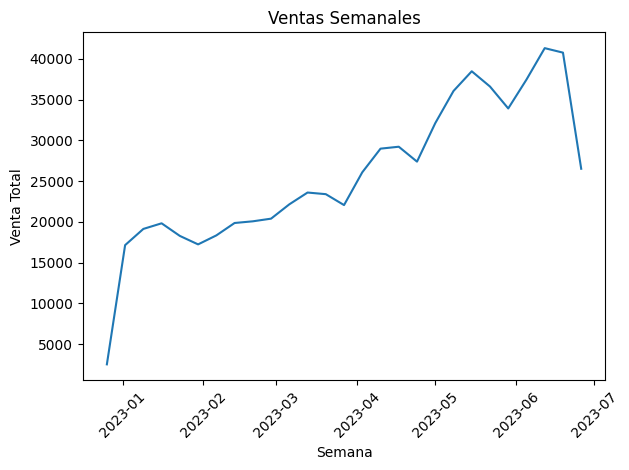

In [32]:
# Visualizar ventas semanales
sns.lineplot(data=ventas_global_semanales, x="week", y="total_sale")
plt.title("Ventas Semanales")
plt.xlabel("Semana")
plt.ylabel("Venta Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

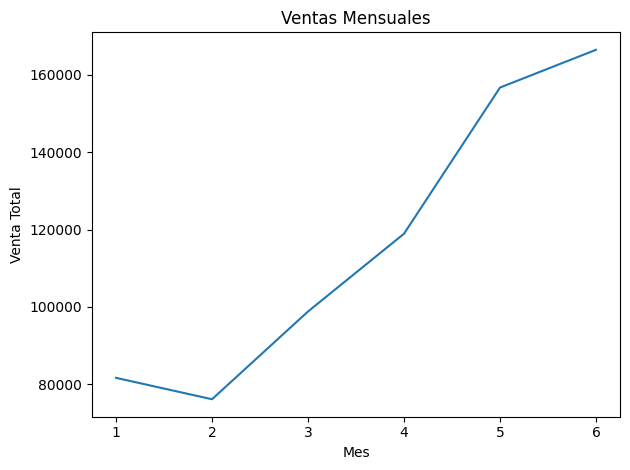

In [33]:
# Visualizar ventas mensuales
sns.lineplot(data=ventas_global_mensuales, x="month", y="total_sale")
plt.title("Ventas Mensuales")
plt.xlabel("Mes")
plt.ylabel("Venta Total")
plt.tight_layout()
plt.show()

### 3.3.2 Gráfico de transacciones

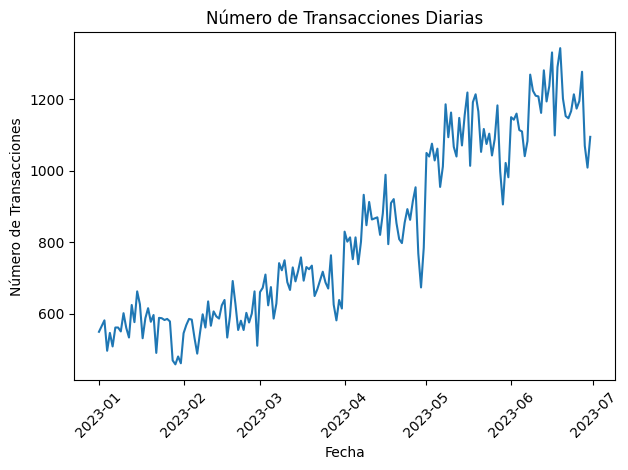

In [34]:
# Visualizar número de transacciones diarias
sns.lineplot(data=ventas_global_diarias, x="transaction_date", y="transactions")
plt.title("Número de Transacciones Diarias")
plt.xlabel("Fecha")
plt.ylabel("Número de Transacciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

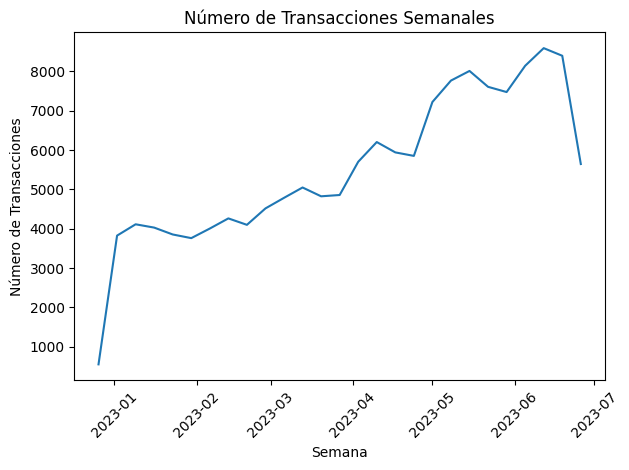

In [35]:
# Visualizar número de transacciones semanalaes
sns.lineplot(data=ventas_global_semanales, x="week", y="transactions")
plt.title("Número de Transacciones Semanales")
plt.xlabel("Semana")
plt.ylabel("Número de Transacciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

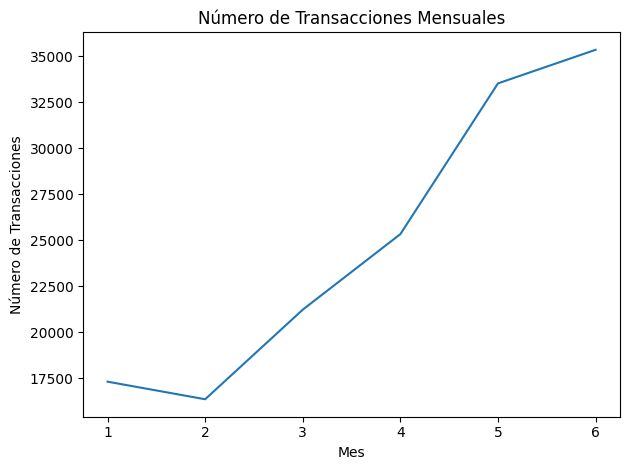

In [36]:
# Visualizar transacciones mensuales
sns.lineplot(data=ventas_global_mensuales, x="month", y="transactions")
plt.title("Número de Transacciones Mensuales")
plt.xlabel("Mes")
plt.ylabel("Número de Transacciones")
plt.tight_layout()
plt.show()

### 2.3.3 Gráfico de ticket promedio

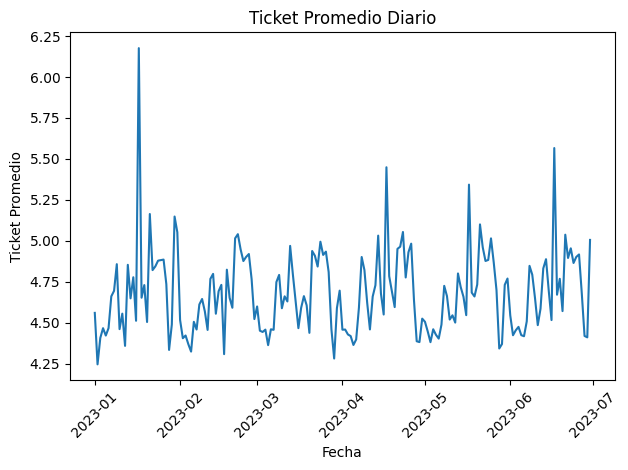

In [37]:
# Visualizar ticket promedio por día
sns.lineplot(data=ventas_global_diarias, x="transaction_date", y="ticket_promedio")
plt.title("Ticket Promedio Diario")
plt.xlabel("Fecha")
plt.ylabel("Ticket Promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

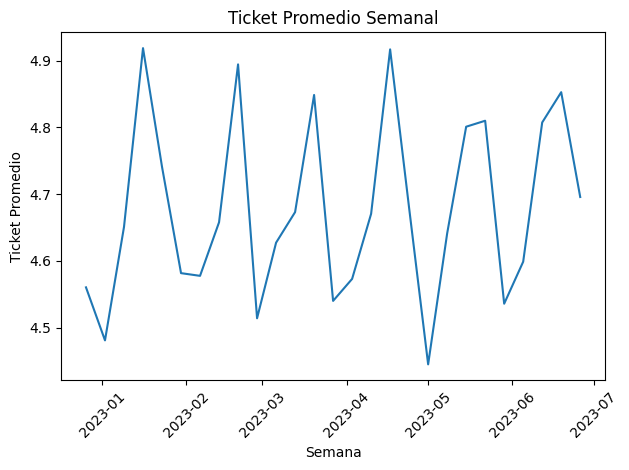

In [38]:
# Visualizar ticket promedio por semana
sns.lineplot(data=ventas_global_semanales, x="week", y="ticket_promedio")
plt.title("Ticket Promedio Semanal")
plt.xlabel("Semana")
plt.ylabel("Ticket Promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

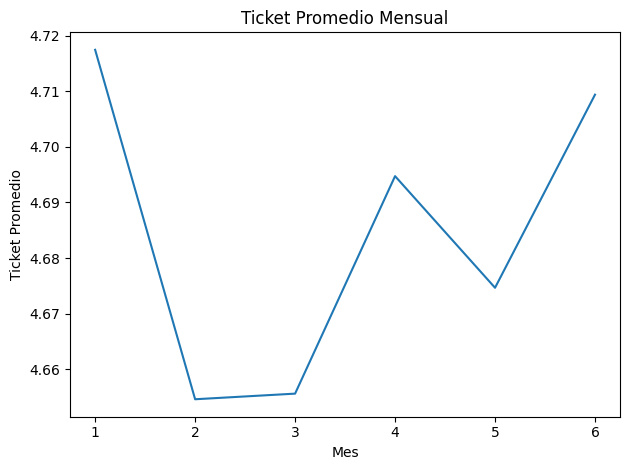

In [39]:
### Visualizar ticket promedio por mes
sns.lineplot(data=ventas_global_mensuales, x="month", y="ticket_promedio")
plt.title("Ticket Promedio Mensual")
plt.xlabel("Mes")
plt.ylabel("Ticket Promedio")
plt.tight_layout()
plt.show()

## 2.4 Resultados del análisis

**Puntos a destacar**
1. Lo que tienen en común cada mes:
- A mediación de cada mes se encuentra los registros más altos de transacciones e ingresos para el mes en cuestión.
- Los últimos días del mes son los peores en el número de ventas.
3. Cada mes hay un aumento de transacciones e ingresos.
4. A partir del mes 4-6 las transacciones y ventas aumentaron casi un 50% en comparación con el primer trimestre del año.

# 3. Desempeño por sucursal

**Objetivo:**  
Estimar el comportamiento futuro de las ventas para los meses julio–diciembre 2023 utilizando la tendencia observada en el periodo enero–junio 2023.

**Tipo de análisis:**  
Predictivo

**Modelo de análisis:**  
Dado que el dataset contiene únicamente 6 meses de información, se utilizará un enfoque basado en tendencia temporal, evitando modelos complejos que requieren mayor cantidad de datos.

## 3.1 Ingresos Mensuales Reales Enero - Junio 2023

In [40]:
# Ventas mensuales por sucursal (enero - junio)
ventas_suc_mes = df.groupby(['month', 'store_location'])['total_sale'].sum().reset_index()
ventas_suc_mes.columns = ['month', 'store_location', 'ingresos']
ventas_suc_mes

,month,store_location,ingresos
0,1,Astoria,27313.66
1,1,Hell's Kitchen,27820.65
2,1,Lower Manhattan,26543.43
3,2,Astoria,25105.34
4,2,Hell's Kitchen,25719.80
5,2,Lower Manhattan,25320.05
6,3,Astoria,32835.43
7,3,Hell's Kitchen,33110.57
8,3,Lower Manhattan,32888.68
9,4,Astoria,39477.61


## 3.2 Ingresos Mensuales Proyectados Julio - Diciembre 2023

In [41]:
# Proyección lineal julio–diciembre por sucursal Regresión Lineal
# x = (7 - 12), conocido_y = (ganancias de los meses Enero - Junio), conocido_x = (1 - 6)
from scipy import stats
meses_reales = [1, 2, 3, 4, 5, 6]
meses_proyeccion = [7, 8, 9, 10, 11, 12]
sucursales = df['store_location'].unique()

proyecciones = []

print("Coeficiente de correlación por sucursal:")
for suc in sucursales:
    datos_suc = ventas_suc_mes[ventas_suc_mes['store_location'] == suc]
    conocido_y = datos_suc['ingresos'].values
    conocido_x = meses_reales

    slope, intercept, r, _, _ = stats.linregress(conocido_x, conocido_y)
    r2 = r ** 2 * 100

    confiable = "Confiable" if r2 >= 50 else "Poco confiable"
    print(f"-{suc}: R² = {r2:.2f}%  ->  {confiable}")

    # y = mx + b -> y = Proyecciones, m = slope, x = mes(7-12), b = intercept
    for mes in meses_proyeccion:
        ingreso_proy = slope * mes + intercept
        proyecciones.append({
            'month': mes,
            'store_location': suc,
            'ingresos_proyectados': round(ingreso_proy, 2)
        })

df_proyeccion = pd.DataFrame(proyecciones)
df_proyeccion

Coeficiente de correlación por sucursal:
-Lower Manhattan: R² = 93.02%  ->  Confiable
-Hell's Kitchen: R² = 92.29%  ->  Confiable
-Astoria: R² = 91.66%  ->  Confiable


,month,store_location,ingresos_proyectados
0,7,Lower Manhattan,60835.08
1,8,Lower Manhattan,67261.42
2,9,Lower Manhattan,73687.76
3,10,Lower Manhattan,80114.11
4,11,Lower Manhattan,86540.45
5,12,Lower Manhattan,92966.79
6,7,Hell's Kitchen,62769.84
7,8,Hell's Kitchen,69441.64
8,9,Hell's Kitchen,76113.45
9,10,Hell's Kitchen,82785.25


## 3.3 Tendencia que se tuvo de Enero a Junio por Sucursal

In [42]:
print("Tendencia de crecimiento enero–junio por sucursal:")
for suc in sucursales:
    datos_suc = ventas_suc_mes[ventas_suc_mes['store_location'] == suc]
    primer_mes = datos_suc['ingresos'].iloc[0]
    ultimo_mes = datos_suc['ingresos'].iloc[-1]
    cambio = ((ultimo_mes - primer_mes) / primer_mes * 100).round(2)
    print(f"-{suc}: {cambio:+.2f}%")

Tendencia de crecimiento enero–junio por sucursal:
-Lower Manhattan: +105.12%
-Hell's Kitchen: +104.73%
-Astoria: +101.67%


## 3.4 Visualización de Datos

### 3.4.1 Astoria - Ingresos Reales vs Ingresos Proyectados

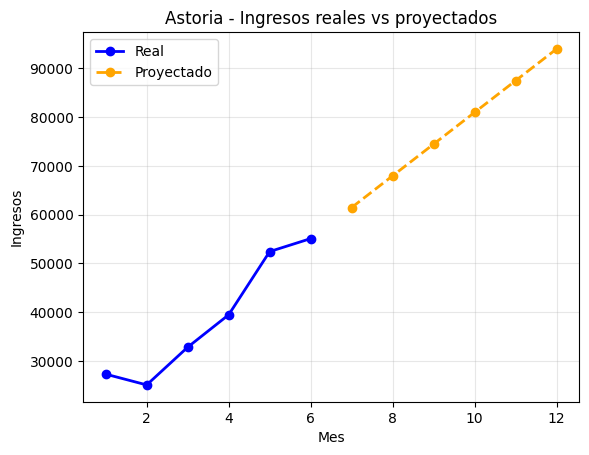

In [43]:
# Astoria
real = ventas_suc_mes[ventas_suc_mes['store_location'] == 'Astoria']
proy = df_proyeccion[df_proyeccion['store_location'] == 'Astoria']

plt.plot(real['month'], real['ingresos'], marker='o', label='Real', color='blue', linewidth=2)
plt.plot(proy['month'], proy['ingresos_proyectados'], marker='o', linestyle='--', label='Proyectado', color='orange', linewidth=2)
plt.title('Astoria - Ingresos reales vs proyectados')
plt.xlabel('Mes')
plt.ylabel('Ingresos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.4.2 Hell's Kitchen - Ingresos Reales vs Ingresos Proyectados

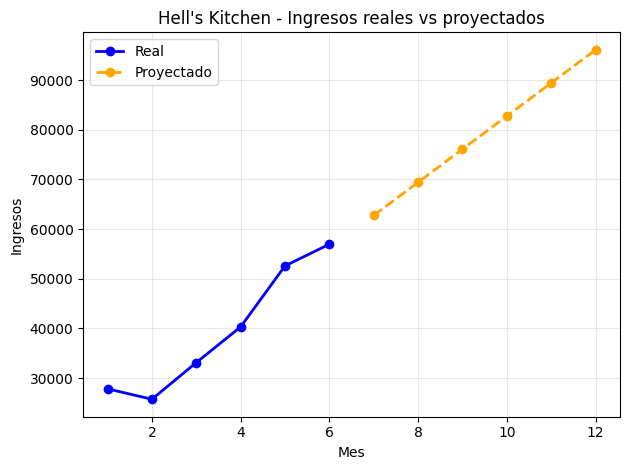

In [44]:
# Hell's Kitchen
real = ventas_suc_mes[ventas_suc_mes['store_location'] == "Hell's Kitchen"]
proy = df_proyeccion[df_proyeccion['store_location'] == "Hell's Kitchen"]

plt.plot(real['month'], real['ingresos'], marker='o', label='Real', color='blue', linewidth=2)
plt.plot(proy['month'], proy['ingresos_proyectados'], marker='o', linestyle='--', label='Proyectado', color='orange', linewidth=2)
plt.title("Hell's Kitchen - Ingresos reales vs proyectados")
plt.xlabel('Mes')
plt.ylabel('Ingresos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4.3 Lower Manhattan - Ingresos Reales vs Ingresos Proyectados

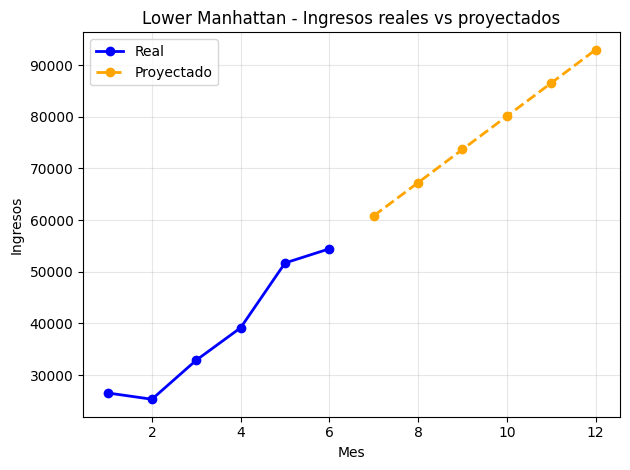

In [45]:
# Lower Manhattan
real = ventas_suc_mes[ventas_suc_mes['store_location'] == 'Lower Manhattan']
proy = df_proyeccion[df_proyeccion['store_location'] == 'Lower Manhattan']

plt.plot(real['month'], real['ingresos'], marker='o', label='Real', color='blue', linewidth=2)
plt.plot(proy['month'], proy['ingresos_proyectados'], marker='o', linestyle='--', label='Proyectado', color='orange', linewidth=2)
plt.title('Lower Manhattan - Ingresos reales vs proyectados')
plt.xlabel('Mes')
plt.ylabel('Ingresos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 Resultados del Analisis

**Tendencia observada enero–junio:**
- Hell's Kitchen: +104.73% de crecimiento (de $27,820.65 a $56,957.08)
- Astoria: +101.67% de crecimiento (de $27,313.66 a $55,083.11)
- Lower Manhattan: +105.12% de crecimiento (de $26,543.43 a $54,445.69)

Las 3 sucursales mostraron crecimiento constante durante el primer semestre, siendo Lower Manhattan la de mayor crecimiento porcentual aunque la de menores ingresos en junio.

**Confiabilidad del modelo:**
- Lower Manhattan: R² = 93.02% - Confiable
- Hell's Kitchen: R² = 92.29% - Confiable
- Astoria: R² = 91.66% - Confiable

Los 3 modelos superan el 50% de R², lo que indica que la tendencia lineal explica bien el comportamiento de las ventas.

**Proyección julio–diciembre:**
- Hell's Kitchen: $62,769.84 en julio - $96,128.86 en diciembre
- Astoria: $61,453.29 en julio - $93,947.53 en diciembre
- Lower Manhattan: $60,835.08 en julio - $92,966.79 en diciembre

Hell's Kitchen proyecta los mayores ingresos para el segundo semestre, manteniendo el liderazgo que tuvo en junio.

# 4. Productos comprados frecuentemente   

**Objetivo:**  
Predecir qué productos interesan más a los clientes 

**Tipo de análisis:**   
Predictivo 

**Modelo de análisis:**  
Analizar las compras de productos para identificar qué productos 
tienen mayor popularidad. Generar sugerencias automáticas basadas en éxitos de ventas. 

In [46]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_location', 'unit_price', 'product_category',
       'product_type', 'total_sale', 'month', 'weekday', 'number_day', 'hour',
       'week', 'number_week'],
      dtype='object')

In [47]:
productos_mas_vendidos = df.groupby("product_type")["transaction_qty"].sum().nlargest(3).reset_index()
print("Productos más vendidos:\n", productos_mas_vendidos)

Productos más vendidos:
             product_type  transaction_qty
0        Brewed Chai tea            26250
1  Gourmet brewed coffee            25973
2       Barista Espresso            24943


In [48]:
lista_mejores_prodeuctos = productos_mas_vendidos["product_type"].tolist()
historial_mejores = df[df['product_type'].isin(lista_mejores_prodeuctos)].sort_values(by=['product_type', 'transaction_date'])
historial_mejores.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,total_sale,month,weekday,number_day,hour,week,number_week
8,9,2023-01-01,07:39:13,1,Lower Manhattan,4.25,Coffee,Barista Espresso,4.25,1,6,1,7,2022-12-26,52
14,15,2023-01-01,07:52:36,2,Lower Manhattan,3.00,Coffee,Barista Espresso,6.00,1,6,1,7,2022-12-26,52
24,25,2023-01-01,08:31:23,1,Hell's Kitchen,3.75,Coffee,Barista Espresso,3.75,1,6,1,8,2022-12-26,52
29,30,2023-01-01,08:41:57,2,Hell's Kitchen,3.75,Coffee,Barista Espresso,7.50,1,6,1,8,2022-12-26,52
30,31,2023-01-01,08:52:03,1,Hell's Kitchen,3.75,Coffee,Barista Espresso,3.75,1,6,1,8,2022-12-26,52


In [49]:
productos_mas_vendidos = historial_mejores.groupby(["transaction_date","product_type"])["transaction_qty"].sum().reset_index().sort_values(by="transaction_date", ascending=False)
print("Productos más vendidos:\n", productos_mas_vendidos)

Productos más vendidos:
     transaction_date           product_type  transaction_qty
542       2023-06-30  Gourmet brewed coffee              181
541       2023-06-30        Brewed Chai tea              167
540       2023-06-30       Barista Espresso              219
539       2023-06-29  Gourmet brewed coffee              152
538       2023-06-29        Brewed Chai tea              211
..               ...                    ...              ...
3         2023-01-02       Barista Espresso               84
5         2023-01-02  Gourmet brewed coffee              115
2         2023-01-01  Gourmet brewed coffee               92
1         2023-01-01        Brewed Chai tea              114
0         2023-01-01       Barista Espresso              109

[543 rows x 3 columns]


In [50]:
productos_mas_vendidos

,transaction_date,product_type,transaction_qty
542,2023-06-30,Gourmet brewed coffee,181
541,2023-06-30,Brewed Chai tea,167
540,2023-06-30,Barista Espresso,219
539,2023-06-29,Gourmet brewed coffee,152
538,2023-06-29,Brewed Chai tea,211
...,...,...,...
3,2023-01-02,Barista Espresso,84
5,2023-01-02,Gourmet brewed coffee,115
2,2023-01-01,Gourmet brewed coffee,92
1,2023-01-01,Brewed Chai tea,114


In [51]:
df_filtrado = productos_mas_vendidos[productos_mas_vendidos["product_type"] == "Brewed Chai tea"]

df_filtrado.head()

,transaction_date,product_type,transaction_qty
541,2023-06-30,Brewed Chai tea,167
538,2023-06-29,Brewed Chai tea,211
535,2023-06-28,Brewed Chai tea,181
532,2023-06-27,Brewed Chai tea,278
529,2023-06-26,Brewed Chai tea,179


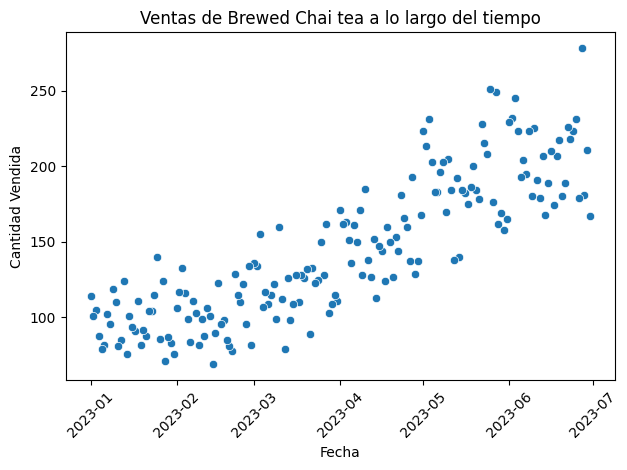

In [52]:
sns.scatterplot(data=df_filtrado, x="transaction_date", y="transaction_qty")
plt.title("Ventas de Brewed Chai tea a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad Vendida")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [53]:
productos_menos_vendidos = df.groupby("product_type")["transaction_qty"].sum().nsmallest(5).reset_index()
print("Productos menos vendidos:\n", productos_menos_vendidos)


Productos menos vendidos:
         product_type  transaction_qty
0        Green beans              134
1          Green tea              159
2  House blend Beans              183
3           Clothing              221
4  Organic Chocolate              221


# 5. Análisis de horarios pico

**Objetivo:**  
Identificar las horas con mayor concurrencia de clientes y volúmenes de 
ventas.  

**Tipo de análisis:**  
Descriptivo

**Modelo de análisis:**  
Analizar las ventas a lo largo del día para identificar en qué horas 
se concentra la mayor cantidad de transacciones. Evaluar la frecuencia de compras 
y el volumen de ingresos por hora para detectar patrones de comportamiento de los 
clientes y determinar los horarios de mayor actividad.

### 5.1 Agregación de datos por hora

In [54]:
# Transacciones e ingresos por hora y sucursal
ventas_suc = df.groupby(['hour', 'store_location'])['transaction_id'].count().reset_index()
ventas_suc.columns = ['hour', 'store_location', 'num_compras']

ingresos_suc = df.groupby(['hour', 'store_location'])['total_sale'].sum().reset_index()
ingresos_suc.columns = ['hour', 'store_location', 'ingreso_total']
# Demanda e ingresos por hora y sucursal
ventas_suc['ingreso_total'] = ingresos_suc['ingreso_total']
ventas_suc

,hour,store_location,num_compras,ingreso_total
0,6,Hell's Kitchen,1676,7531.17
1,6,Lower Manhattan,2918,14369.10
2,7,Astoria,4181,19028.80
3,7,Hell's Kitchen,3455,15961.05
4,7,Lower Manhattan,5792,28536.62
5,8,Astoria,4966,22805.90
6,8,Hell's Kitchen,6909,31544.44
7,8,Lower Manhattan,5779,28349.53
8,9,Astoria,5083,23183.57
9,9,Hell's Kitchen,6767,32874.29


In [58]:

df.pivot_table(values=['transaction_id', 'total_sale'], index='hour', aggfunc={'transaction_id': 'count', 'total_sale': 'sum'})

,total_sale,transaction_id
hour,,
6,21900.27,4594
7,63526.47,13428
8,82699.87,17654
9,85169.53,17764
10,88673.39,18545
11,46319.14,9766
12,40192.79,8708
13,40367.45,8714
14,41304.74,8933


In [ ]:
#Transacciones e ingresos totales por hora (3 sucursales sumadas)
compras_por_hora = df['hour'].value_counts().sort_index()
ingresos_por_hora = df.groupby('hour')['total_sale'].sum().sort_index()

hora_pico_tx  = compras_por_hora.idxmax()
valor_pico_tx = compras_por_hora.max()
hora_pico_ing  = ingresos_por_hora.idxmax()
valor_pico_ing = ingresos_por_hora.max()

print(f'Hora con mas transacciones: {hora_pico_tx}:00 h ({valor_pico_tx:,} compras)')
print(f'Hora con mayor ingreso:     {hora_pico_ing}:00 h (${valor_pico_ing:,.2f})')

Hora con mas transacciones: 10:00 h (18,545 compras)
Hora con mayor ingreso:     10:00 h ($88,673.39)


### 5.2 Comportamiento por hora

In [ ]:
umbral_alto = compras_por_hora.quantile(0.75)
umbral_bajo = compras_por_hora.quantile(0.25)

horas_altas = compras_por_hora[compras_por_hora >= umbral_alto].index.tolist()
horas_bajas = compras_por_hora[compras_por_hora <= umbral_bajo].index.tolist()

print(f"Horas de alta demanda (>= p75): {horas_altas}")
print(f"Horas de baja demanda (<= p25): {horas_bajas}")


Horas de alta demanda (>= p75): [7, 8, 9, 10]
Horas de baja demanda (<= p25): [6, 18, 19, 20]



### 5.3 Comparación por Sucursal


In [ ]:
# 5.3 Comparación por sucursal
rendimiento_sucursal = df.groupby('store_location').agg(
    transacciones=('transaction_id', 'count'),
    ingresos=('total_sale', 'sum')
).reset_index()

rendimiento_sucursal['participacion_%'] = (
    rendimiento_sucursal['transacciones'] / rendimiento_sucursal['transacciones'].sum() * 100
).round(2)

# Hora pico por sucursal
hora_pico_suc = ventas_suc.loc[ventas_suc.groupby('store_location')['num_compras'].idxmax()][['store_location','hour','num_compras']]

print("Rendimiento general:")
print(rendimiento_sucursal[['store_location','transacciones','ingresos','participacion_%']].to_string(index=False))



Rendimiento general:
 store_location  transacciones  ingresos  participacion_%
        Astoria          50599 232243.91            33.93
 Hell's Kitchen          50735 236511.17            34.02
Lower Manhattan          47782 230057.25            32.04


## 5.2 Visualización de datos

### 5.2.1 Transacciones e ingresos por hora (3 sucursales sumadas)

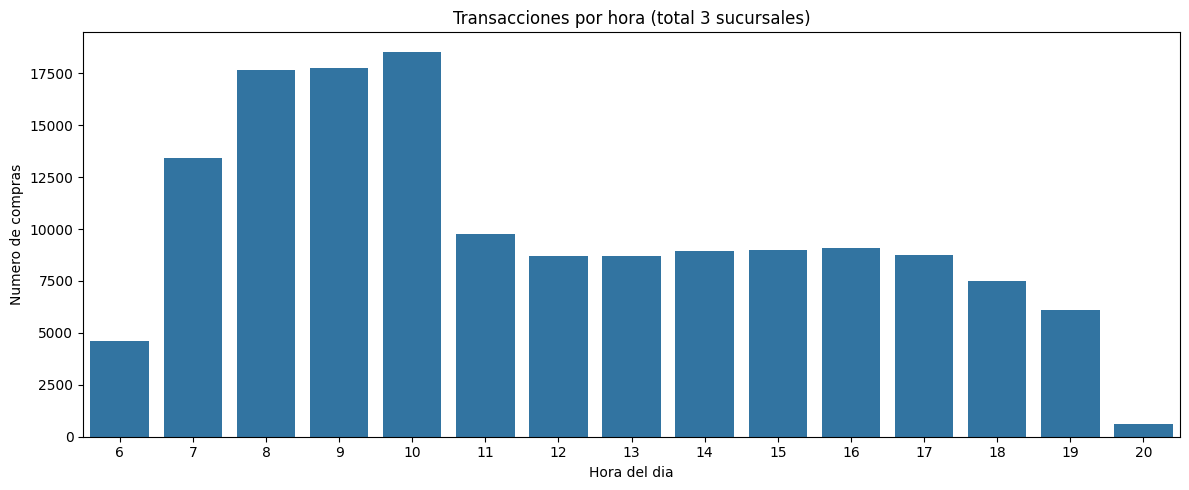

In [ ]:
# Transacciones por hora
plt.figure(figsize=(12, 5))
sns.barplot(x=compras_por_hora.index, y=compras_por_hora.values)
plt.title('Transacciones por hora (total 3 sucursales)')
plt.xlabel('Hora del dia')
plt.ylabel('Numero de compras')
plt.tight_layout()
plt.show()

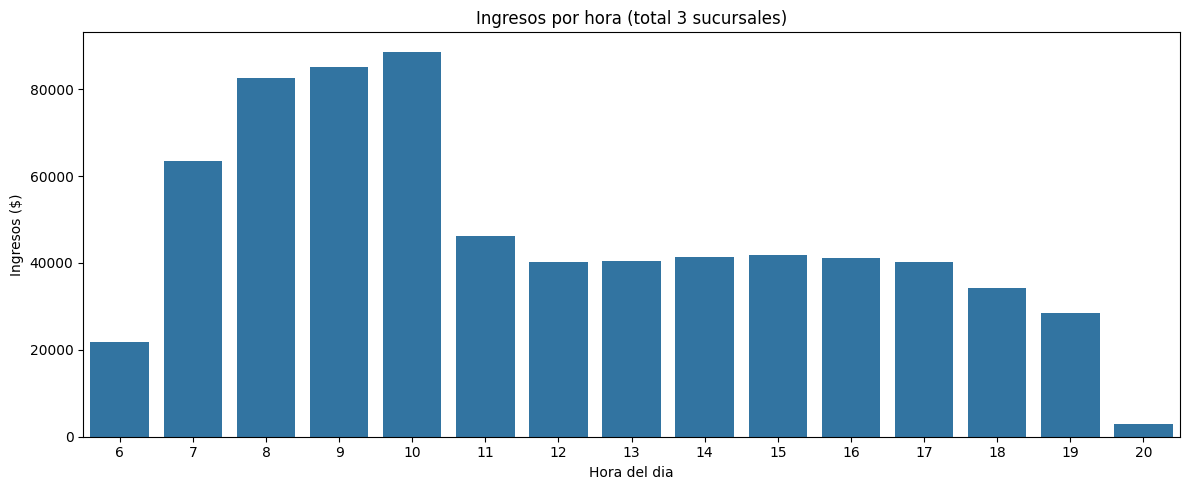

In [ ]:
# Ingresos por hora
plt.figure(figsize=(12, 5))
sns.barplot(x=ingresos_por_hora.index, y=ingresos_por_hora.values)
plt.title('Ingresos por hora (total 3 sucursales)')
plt.xlabel('Hora del dia')
plt.ylabel('Ingresos ($)')
plt.tight_layout()
plt.show()

### 5.2.2 Demanda e ingresos de las 3 sucursales por hora

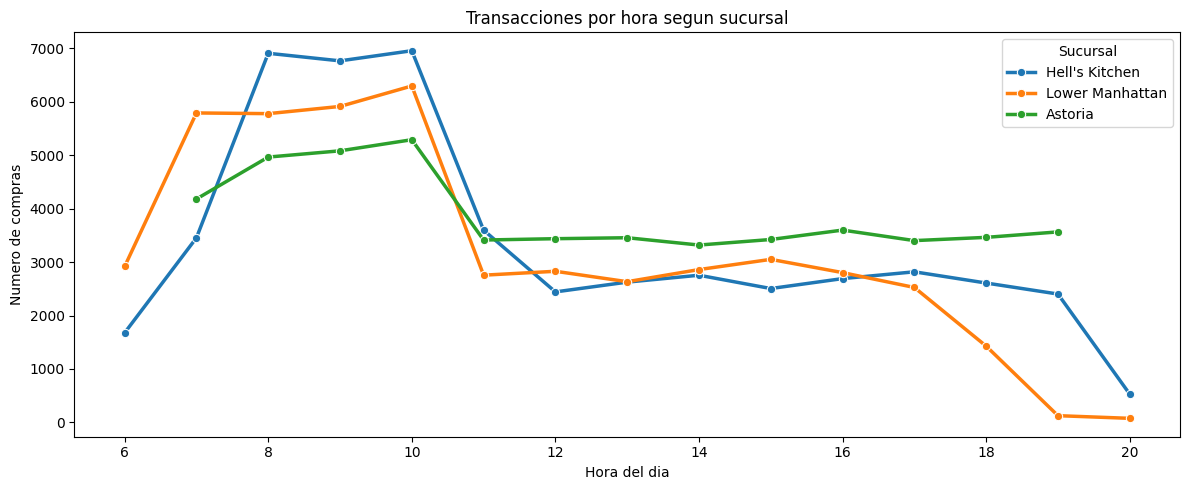

In [ ]:
# Transacciones por hora segun sucursal
plt.figure(figsize=(12, 5))
sns.lineplot(data=ventas_suc, x='hour', y='num_compras',
             hue='store_location', marker='o', linewidth=2.5)
plt.title('Transacciones por hora segun sucursal')
plt.xlabel('Hora del dia')
plt.ylabel('Numero de compras')
plt.legend(title='Sucursal')
plt.tight_layout()
plt.show()

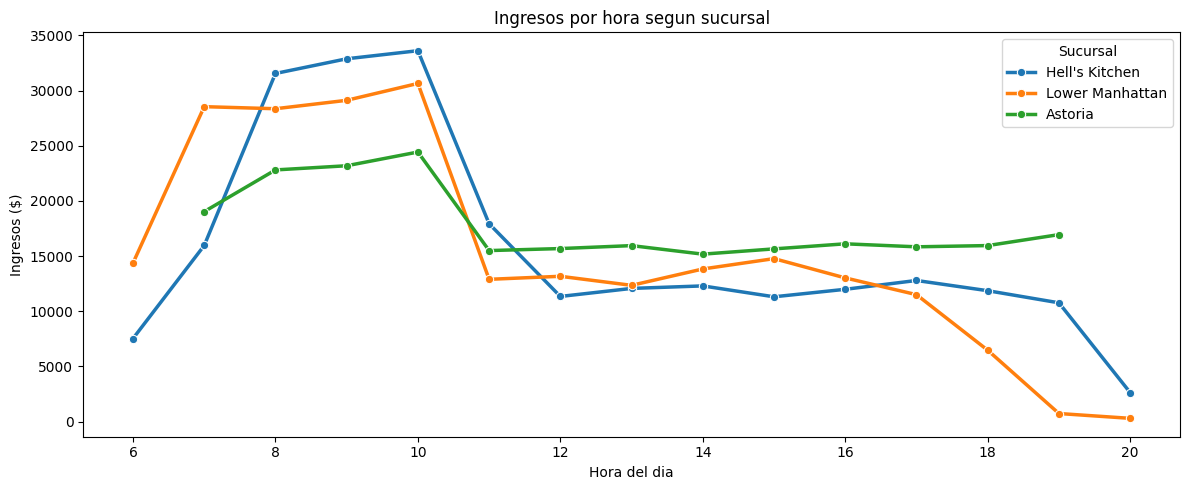

In [ ]:
# Ingresos por hora segun sucursal
plt.figure(figsize=(12, 5))
sns.lineplot(data=ingresos_suc, x='hour', y='ingreso_total',
             hue='store_location', marker='o', linewidth=2.5)
plt.title('Ingresos por hora segun sucursal')
plt.xlabel('Hora del dia')
plt.ylabel('Ingresos ($)')
plt.legend(title='Sucursal')
plt.tight_layout()
plt.show()

### 5.2.3 Heatmaps por hora y día de la semana (3 sucursales sumadas)

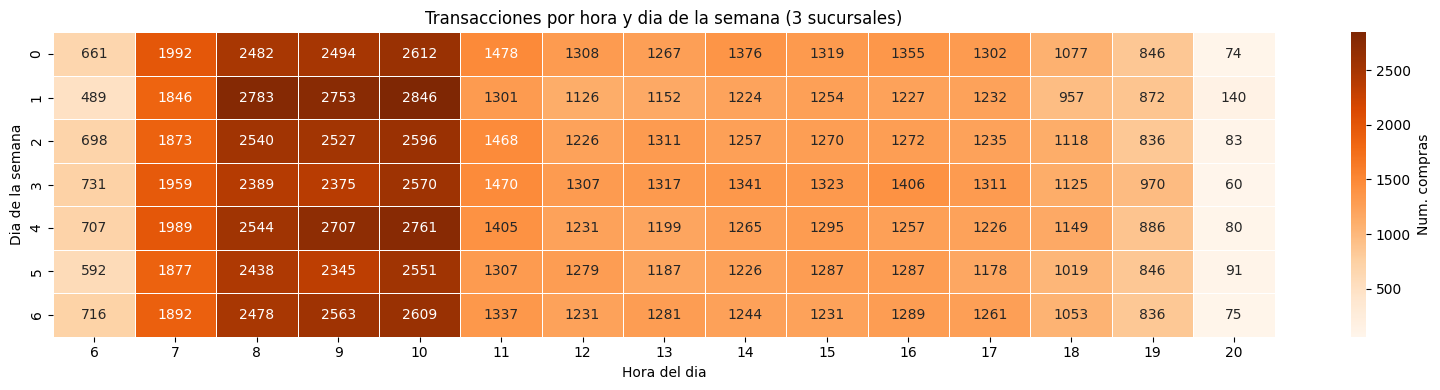

In [ ]:
# Heatmap transacciones por hora y dia de la semana
heatmap_tx_dia = df.pivot_table(
    values='transaction_id',
    index='weekday',
    columns='hour',
    aggfunc='count'
)

plt.figure(figsize=(16, 4))
sns.heatmap(heatmap_tx_dia, cmap='Oranges', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Num. compras'})
plt.title('Transacciones por hora y dia de la semana (3 sucursales)')
plt.xlabel('Hora del dia')
plt.ylabel('Dia de la semana')
plt.tight_layout()
plt.show()

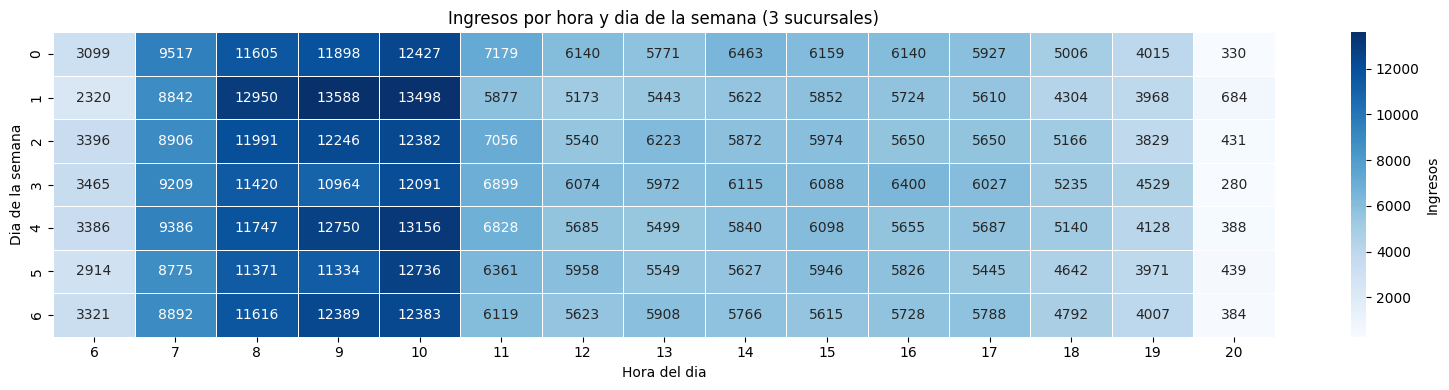

In [ ]:
# Heatmap ingresos por hora y dia de la semana
heatmap_ing_dia = df.pivot_table(
    values='total_sale',
    index='weekday',
    columns='hour',
    aggfunc='sum'
)

plt.figure(figsize=(16, 4))
sns.heatmap(heatmap_ing_dia, cmap='Blues', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Ingresos'})
plt.title('Ingresos por hora y dia de la semana (3 sucursales)')
plt.xlabel('Hora del dia')
plt.ylabel('Dia de la semana')
plt.tight_layout()
plt.show()

### 5.2.4 Heatmaps por hora para cada sucursal

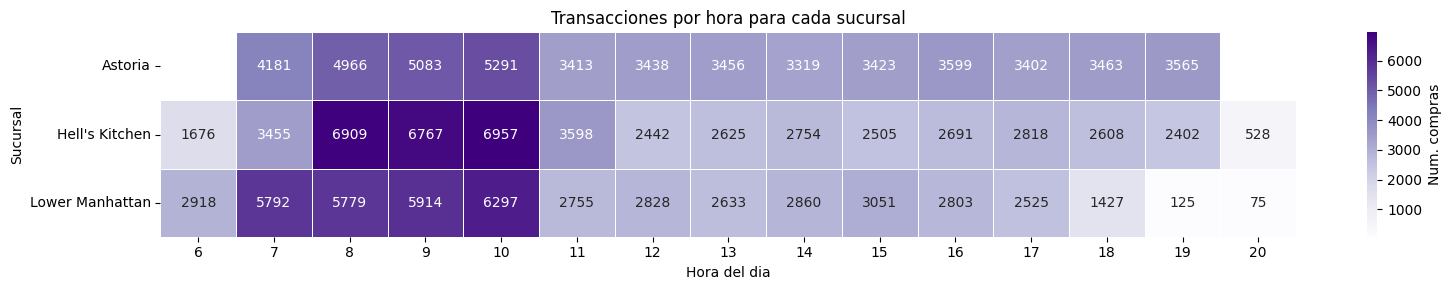

In [ ]:
# Heatmap transacciones por hora y sucursal
heatmap_tx_suc = df.pivot_table(
    values='transaction_id',
    index='store_location',
    columns='hour',
    aggfunc='count'
)

plt.figure(figsize=(16, 3))
sns.heatmap(heatmap_tx_suc, cmap='Purples', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Num. compras'})
plt.title('Transacciones por hora para cada sucursal')
plt.xlabel('Hora del dia')
plt.ylabel('Sucursal')
plt.tight_layout()
plt.show()

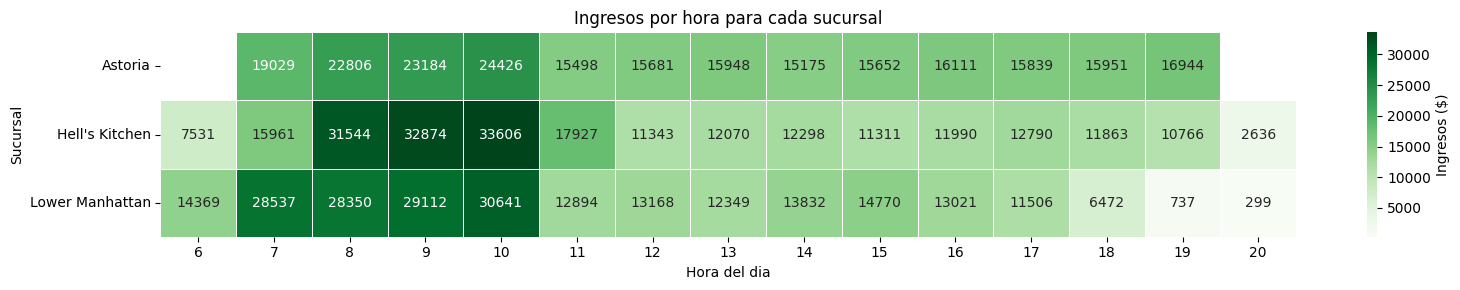

In [ ]:
# Heatmap ingresos por hora y sucursal
heatmap_ing_suc = df.pivot_table(
    values='total_sale',
    index='store_location',
    columns='hour',
    aggfunc='sum'
)

plt.figure(figsize=(16, 3))
sns.heatmap(heatmap_ing_suc, cmap='Greens', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Ingresos ($)'})
plt.title('Ingresos por hora para cada sucursal')
plt.xlabel('Hora del dia')
plt.ylabel('Sucursal')
plt.tight_layout()
plt.show()

## 5.3 Resultados del análisis


1. **Hora pico general:** La mayor concentración de compras ocurre a las **10:00 h**, con 18,545 transacciones. El rango de mayor actividad se extiende de las **8:00 a las 11:00 h**, correspondiendo al horario matutino típico de una cafetería.

2. **Caída después del pico:** A partir de las 11:00 h la demanda cae considerablemente y se mantiene relativamente estable entre las 12:00 y las 17:00 h. Después de las 19:00 h la actividad es mínima.

3. **Comportamiento por día de la semana:** Los días entre semana presentan picos matutinos más pronunciados. 


# 6. Categorías y productos

# prueba

In [ ]:


ventas_total_semanal = df.groupby("number_week", as_index=False)["total_sale"].sum()
ventas_total_semanal.index = ventas_total_semanal["number_week"].dt.start_time
del ventas_total_semanal["number_week"]
ventas_sucursal_semanal = df.groupby(["number_week", "store_location"], as_index=False)["total_sale"].sum()
ventas_sucursal_semanal["number_week"] = ventas_sucursal_semanal["number_week"].dt.start_time

ventas_total_mensual = df.groupby("month", as_index=False)["total_sale"].sum()
ventas_sucursal_mensual = df.groupby(["month", "store_location"], as_index=False)["total_sale"].sum()

AttributeError: Can only use .dt accessor with datetimelike values

## 2.1 Ventas diarias

In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=ventas_total_diarias, x="transaction_date", y="total_sale")
plt.title("Ventas diarias totales")
plt.xlabel("Fecha de transacción")
plt.ylabel("Total de ventas")
plt.show()

In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=ventas_sucursal_diarias, x="transaction_date", y="total_sale", hue="store_location")
plt.title("Ventas diarias por sucursal")
plt.xlabel("Fecha de transacción")
plt.ylabel("Total de ventas")
plt.legend(title="Sucursal")
plt.show()

## 2.2 Ventas semanales

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=ventas_total_semanal, x="number_week", y="total_sale")
plt.title("Ventas semanales totales")
plt.xlabel("Número de semana")
plt.ylabel("Total de ventas")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=ventas_sucursal_semanal, x="number_week", y="total_sale", hue="store_location")
plt.title("Ventas semanales por sucursal")
plt.xlabel("Número de semana")
plt.ylabel("Total de ventas")
plt.legend(title="Sucursal")
plt.show()

## 2.3 Ventas mensuales

In [ ]:
sns.lineplot(data=ventas_total_mensual, x="month", y="total_sale")
plt.title("Ventas mensuales totales")
plt.xlabel("Mes")
plt.ylabel("Total de ventas")
plt.show()

In [ ]:
sns.lineplot(data=ventas_sucursal_mensual, x="month", y="total_sale", hue="store_location")
plt.title("Ventas mensuales por sucursal")
plt.xlabel("Mes")
plt.ylabel("Total de ventas")
plt.legend(title="Sucursal")
plt.show()